In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
from parsing_library import *
import json

/pdc/software/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/pdc/software/23.12/eb/software/anaconda3/2024.02-1-cpeGNU-23.12/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


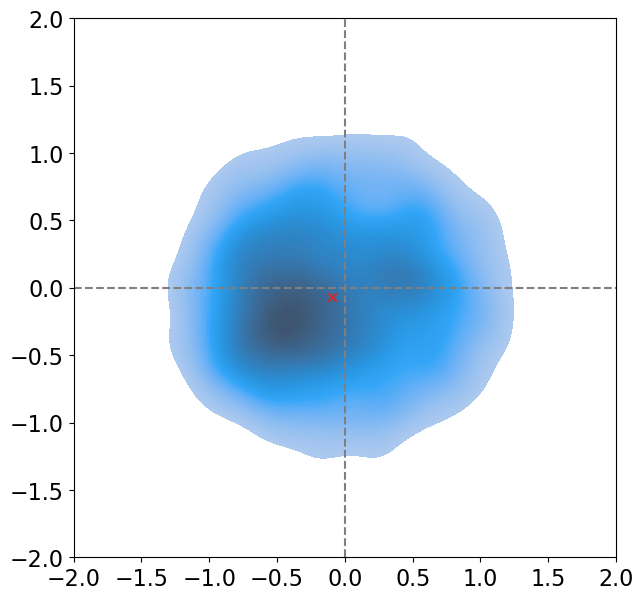

In [51]:
word_index = 4
size = 50000
#data = '../../new_sims_jan25/ten_V100_K'
data = '../../data/ten_V100K5/1.json'
saved_fits_dir = '../../results_ten_V100K5/nofix/hmc/1'
inference_method = 'hmc'
D = 5

with open(data) as f:
    data = json.load(f)

vocabulary = data['vocabulary']


fit = load_fit_by_size(size, saved_fits_dir)
fit = {'word_vectors':fit['word_vectors'], 'context_vectors':fit['context_vectors']}

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(7, 7))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')


#plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')




plt.show()

In [52]:
### K = 5 FIXX


word_index = 4
size = 50000
#data = '../../new_sims_jan25/ten_V100_K'
data = '../../data/ten_V100K5/1.json'
saved_fits_dir = '../../results50k_V100K5/fix/vi/1'
inference_method = 'vi'
D = 5

with open(data) as f:
    data = json.load(f)

vocabulary = data['vocabulary']


fit = load_fit_by_size(size, saved_fits_dir)
fit = {'word_vectors':fit['word_vectors'], 'context_vectors':fit['context_vectors']}

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(7, 7))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')


#plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')




plt.show()

no fit of size 50000 in ../../results50k_V100K5/fix/vi/1


TypeError: 'NoneType' object is not subscriptable

In [11]:
np.shape(fit['context_vectors'][:,:,0][-5:])

(5, 5)

In [14]:
fit['context_vectors'][:,:,0][0:5]

array([[ 0.2929228 , -0.10819802,  0.03476141,  0.81489018,  0.08261522],
       [ 0.00438147,  0.57757592, -0.34421721,  0.11241055, -0.04529787],
       [ 0.046894  , -0.63304982, -0.3328374 , -0.1979924 ,  0.17070582],
       [-0.58259966,  0.27560963,  0.73874419,  0.67337119,  0.59689944],
       [-0.25967045, -0.31191875,  0.61804239,  0.54858536,  0.41154047]])

In [15]:
fit['context_vectors'][:,:,10][:5]

array([[ 0.69546862, -0.18420127, -0.23392505,  1.25678255, -0.38681128],
       [ 0.45642397,  0.40428568, -0.56490071,  0.00814496, -0.08188527],
       [ 0.39326715, -1.14377672, -0.24568897, -0.76581043, -0.21590465],
       [-0.34051855,  0.17961469,  0.21506594,  0.47727307,  0.52301072],
       [ 0.9490663 ,  0.33023521, -0.28983879,  0.09456727,  0.38156664]])

In [33]:

import pickle

fit = load_fit_by_size(50000, '../../results50k_V100K5/fix/hmc/1')

In [37]:
fit['context_vectors'][:,:,0][-6:]

array([[ 0.43116337, -0.25450557,  0.31595413, -0.27847005,  0.25986303],
       [ 0.362597  ,  0.286789  , -0.149239  , -0.116751  ,  0.328811  ],
       [-0.0187337 , -0.458969  , -0.10406   ,  0.0192416 , -0.397921  ],
       [-0.515548  ,  1.29205   ,  0.397466  ,  0.619192  ,  0.442292  ],
       [-0.0208391 ,  0.570152  ,  0.0911178 , -0.0472029 , -0.54099   ],
       [ 0.288633  , -0.228254  , -0.599517  ,  0.0996732 ,  0.388289  ]])

In [39]:
fit['context_vectors'][:,:,100][-6:]

array([[ 0.22183672, -0.05899195, -0.44285272,  0.66840949, -0.12645945],
       [ 0.362597  ,  0.286789  , -0.149239  , -0.116751  ,  0.328811  ],
       [-0.0187337 , -0.458969  , -0.10406   ,  0.0192416 , -0.397921  ],
       [-0.515548  ,  1.29205   ,  0.397466  ,  0.619192  ,  0.442292  ],
       [-0.0208391 ,  0.570152  ,  0.0911178 , -0.0472029 , -0.54099   ],
       [ 0.288633  , -0.228254  , -0.599517  ,  0.0996732 ,  0.388289  ]])

In [25]:
np.linalg.cond(fit['context_vectors'][:,:,10][-5:])

5.187286611327333

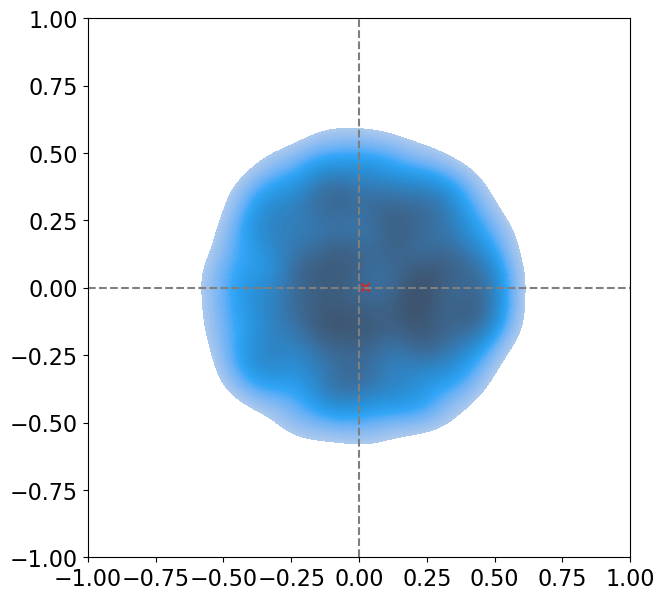